In [301]:
import pandas as pd
import numpy as np
from pathlib import Path
base_path = Path(".") # change to path folder with data 


# Analiza i przetwarzanie danych na temat Titanica

#### Wyobraź sobie, że pewnego wakacyjnego dnia, będąc na plaży w pełnym słońcu, odbierasz telefon od nieznanego numeru.
Robisz to niechętnie — zasłużyłeś/aś przecież na odpoczynek i chcesz mieć ten czas tylko dla siebie. Już masz na końcu języka wymijającą odpowiedź, gdy nagle z drugiej strony słyszysz:
„Czy jesteś gotowy, by tego lata rozwikłać jedną z największych zagadek ludzkości?”

Jako osoba z natury ciekawa świata i ze świetnym umysłem analitycznym, szybko zapominasz o plaży i wakacjach. Zaintrygowany/a dopytujesz o szczegóły, ale rozmówca nie chce zdradzić zbyt wiele. Wiadomo jedynie, że chodzi o *zatonięcie Titanica w 1914* roku, a celem misji jest ustalenie, które osoby miały szansę przeżyć.

**Ty** — jako **renomowany analityk danych** — byłeś/byłaś ich pierwszym wyborem do analizy i oczyszczenia danych. Mimo wątpliwości postanawiasz podjąć się zadania, mając nadzieję, że twoja wiedza może zostać praktycznie wykorzystana w słusznym celu.

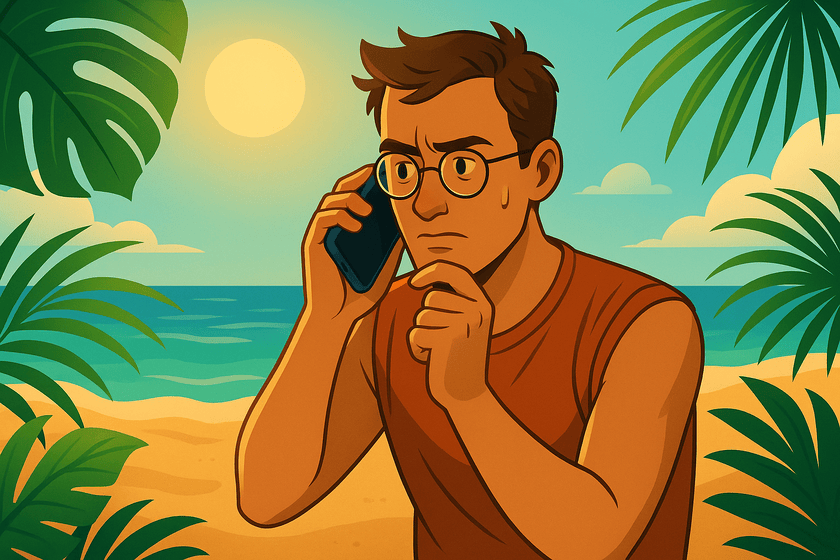

(*AI-generated image*)


#### Twoim celem będzie przeanalizowanie i przetworzenie zbioru danych w taki sposób, by mógł on być użyty do nauki modelu do klasyfikacji każdego pasażera Titanica jako ofiary (0) lub osoby, która przeżyła (1).

(Uwaga: w tym zadaniu nie będziesz trenować modeli, ta przyjemność spotka cię w następnych notebookach)

Poniżej znajdziesz pytania, które mogą być pomocne w analizie, oraz odwołania do poszczególnych sekcji z notebooka do lekcji:

- Czy wszystkie kolumny są istotne w kontekście zadania?
- Czy występują brakujące wartości? Jeśli tak, to jak je uzupełnisz? (sekcja #2.1)
- Czy typy danych są odpowiednie do znaczenia kolumny? (sekcja #1.3)
- Czy dystrybucje danych mają rozkłady normalne, czy asymetryczne? (sekcja #4.1 + wykład)
- Która zmienna oznacza predykowaną klasę?
- Jaki jest rozkład zmiennej predykowanej względem zmiennych kategorialnych, jak i numerycznych? (sekcja #4.1)
- Czy końcowe rozkłady zawierają wartości skrajne? (sekcja #4.2 + wykład)

Wymagania:

- Zbiór musi być oczyszczony, tj. finalnie nie powinien mieć brakujących wartości (sekcja #2.1)
- Zbiór musi zawierać co najmniej dwie dodatkowe kolumny, które mogą wzbogacić informacje zawarte w zbiorze (sekcje #1.5 i #2.2)
- Cechy kategorialne powinny być zakodowane, postaraj się dobrać odpowiedni sposób (sekcja #2.3)
- Zbadaj, czy występują skrajne wartości (outliery) zarówno dla wartości numerycznych, jak i dla kategorialnych
- Każda cecha powinna być zwizualizowana co najmniej raz. Sam(a) zastanów się, czy warto wizualizować cechy parami w celu odkrycia zależności między nimi (sekcja #4.4)
- Nie ma ograniczenia na liczbę komórek, ale zastanów się, czy dana wizualizacja/obliczenie jest przydatne w całej analizie, czy po prostu sobie "egzystuje" bez żadnych wniosków

Zadbaj o czytelność kodu i nazewnictwo zmiennych. Jeśli jakiś wycinek kodu się powtarza, to wyodrębnij go do funkcji. Postaraj się zamieszczać swoje wnioski w postaci komentarza `Markdown`.

Poniżej zamieszczamy tabelę z wyjaśnieniem poszczególnych kolumn:

| Kolumna      | Opis                                                                            |
| ------------ | ------------------------------------------------------------------------------- |
| **Survived** | Czy pasażer przeżył (0 = nie, 1 = tak).                                         |
| **Pclass**   | Klasa podróży (1 = I klasa, 2 = II klasa, 3 = III klasa).                       |
| **Name**     | Imię i nazwisko pasażera.                                                       |
| **Sex**      | Płeć pasażera (male = mężczyzna, female = kobieta).                             |
| **Age**      | Wiek pasażera w latach.                                                         |
| **SibSp**    | Liczba rodzeństwa i małżonków na pokładzie.                                     |
| **Parch**    | Liczba rodziców i dzieci na pokładzie.                                          |
| **Ticket**   | Numer biletu.                                                                   |
| **Fare**     | Cena biletu.                                                                    |
| **Cabin**    | Numer kabiny pasażera                                     |
| **Embarked** | Port, w którym pasażer wsiadł (C = Cherbourg, Q = Queenstown, S = Southampton). |
                                                         |


In [302]:
titanic_df = pd.read_csv(base_path / 'titanic.csv', index_col='PassengerId')

In [303]:
titanic_df.Survived.value_counts(normalize=True)

Survived
0    0.616162
1    0.383838
Name: proportion, dtype: float64

In [304]:
titanic_df['Cabin'].str[0].unique()

array([nan, 'C', 'E', 'G', 'D', 'A', 'B', 'F', 'T'], dtype=object)


### 1. Oczyszczenie zbioru


In [305]:
titanic_df.isna().sum()

Survived      0
Pclass        0
Name          0
Sex           0
Age         177
SibSp         0
Parch         0
Ticket        0
Fare         98
Cabin       687
Embarked      2
dtype: int64

Zauważmy, że brakuje wartości w kolumnach: Age, Fare, Cabin, Embarked
Aby pozbyć się nieznanych wartości w wieku pasażerów uzupełniam je zgodnie z rozkładem istniejących danych, aby nie zaburzyć statystyk.

In [306]:
def get_age_distribution(df, column):
    return df[column].value_counts(normalize=True)
age_proba = get_age_distribution(titanic_df, 'Age')
age_values = age_proba.index
age_proba=age_proba.values
missing_ages=titanic_df['Age'].isna()
titanic_df.loc[missing_ages,'Age'] = np.random.choice(age_values, size=missing_ages.sum(), p=age_proba)
titanic_df['Age'].isna().sum()

np.int64(0)

Dla kabiny mamy wiele nieznanych wartości. Jest to zmienna kategorialna, zatem utorzę osobną kategorię "unknown"

In [307]:
titanic_df['Cabin'] = titanic_df['Cabin'].fillna('unknow')
titanic_df['Cabin'].isna().sum()

np.int64(0)

Embarked jest daną kategorialną. Tylko dwóch danych brakuje, zatem uzupełnie je modami.

In [308]:
titanic_df["Embarked"]= titanic_df["Embarked"].fillna(titanic_df["Embarked"].mode()[0])
titanic_df["Embarked"].isna().sum()

np.int64(0)

Fare to wartość liczbowa, zatem aby określić jak najlepij uzupełnic braki, sprawdzę rozkład ceny biltów.

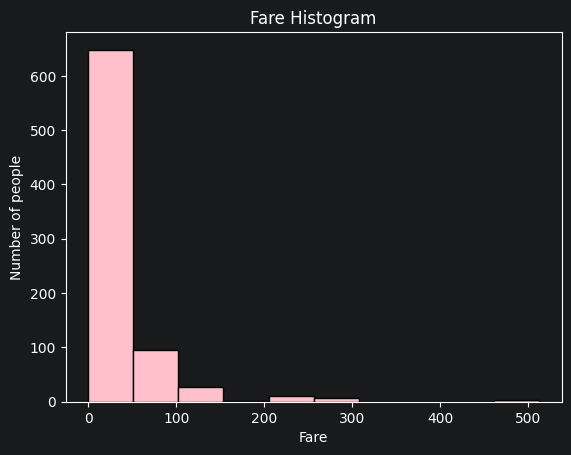

In [309]:
import matplotlib.pyplot as plt
import seaborn as sns
data_fare = titanic_df.Fare

plt.hist(data_fare, bins=10, color='pink', edgecolor='black')
plt.title("Fare Histogram")
plt.xlabel("Fare")
plt.ylabel("Number of people")
plt.show()

Histogram wskazuje na niesymetryczny rozkład, zatem dane uzupełnię medianą.

In [310]:
titanic_df['Fare']=titanic_df['Fare'].fillna(titanic_df['Fare'].median())
titanic_df['Fare'].isna().sum()
titanic_df.isna().sum()

Survived    0
Pclass      0
Name        0
Sex         0
Age         0
SibSp       0
Parch       0
Ticket      0
Fare        0
Cabin       0
Embarked    0
dtype: int64

 ### 2. Dodatkowe kolumny

Zakładam, że na przeżycie mógł mieć wpływ wiek pasażera (szacuję, że dzieci były częściej ratowane), ilość rodziny na pokładzie (szacuję, że częściej umierały osoby bez rodziny na pokładzie) oraz cena biletu (droższy bilet może wskazywać na większe szanse na przetrwanie). Aby sprawdzić te hipotezy, stworzę wykresy zależności przeżycia pasażera w zależności od tych trzech parametrów.

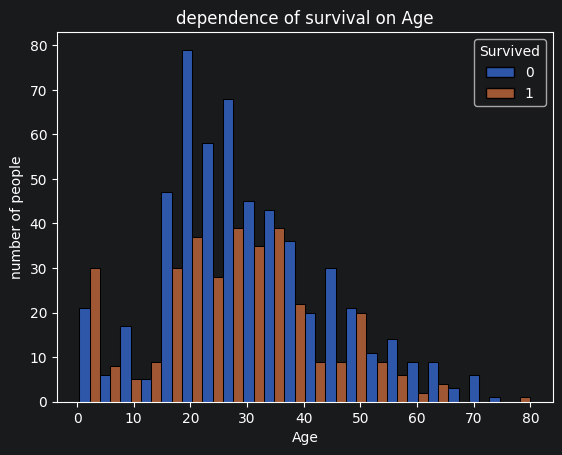

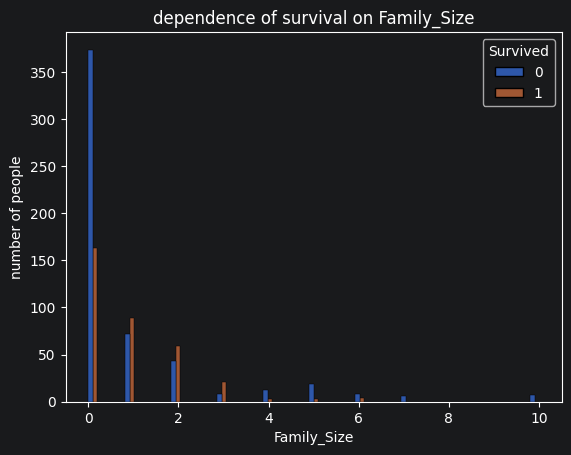

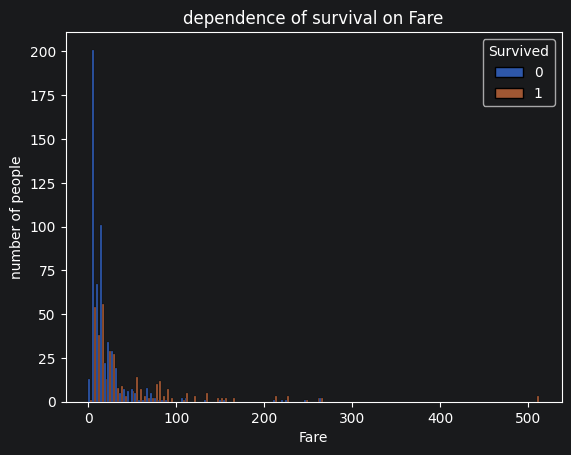

In [311]:
def wykres_przezycia_od_parametru(parametr):
    sns.histplot(data=titanic_df, x=parametr ,hue="Survived", multiple="dodge")
    plt.title("dependence of survival on " + parametr)
    plt.xlabel(parametr)
    plt.ylabel("number of people")
    return plt.show()
wykres_przezycia_od_parametru("Age")
titanic_df['Family_Size']=titanic_df['SibSp']+titanic_df['Parch']
wykres_przezycia_od_parametru("Family_Size")
wykres_przezycia_od_parametru("Fare")

Zauważmy, że małe dzieci mają wiekszą szansę na przeżycie, stosunkowo najwięcej ludzi umierało w grupie wiekowej od 15 do 30 r.ż. Utworzę nową kolumnę, dla której stworzę nowe przedziały wiekowe oznaczone następująco: 1 - wiek od 0 do 5 r.ż.; 2 - od 5 do 15 r.ż.; 3 - od 15 do 30 r.ż.; 4 - od 30 do 50 r.ż.; 5 - od 50 do 100 r.ż.

In [312]:
Fare_Categories= lambda x: 1 if x <10 else(2 if x<25 else(3 if x<50 else(4 if x<100 else(5))))
titanic_df['Fare_Category']=titanic_df['Fare'].apply(Fare_Categories)
titanic_df.head()

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Family_Size,Fare_Category
PassengerId,,,,,,,,,,,,,
1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,unknow,S,1,1
2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,1,4
3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,unknow,S,0,1
4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,1,4
5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,unknow,S,0,1


In [313]:
Age_Categories= lambda x: 1 if x < 5 else(2 if x<15 else(3 if x<30 else(4 if x<50 else(5))))
titanic_df['Age_Category']=titanic_df['Age'].apply(Age_Categories)

Tworząc wykres stworzyłam już kolumnę Family_Size. Stworzę także dodatkową kolumnę przydzielającą wartości w odniesieniu do ceny biletu. Podzieliłam je na kategorię przedstawione za pomocą cyfr: 1 - od 0 do 10; 2 - od 10 do 25; 3 - od 25 do 50; 4 - od 50 do 100; 5 - od 100 do 600

### 3. Kodowanie danych kategorialnych

Dane kategorialne należy zakodować. Dla danych Sex zakoduje je binarnie (0 - male, 1- female), a dla Embarked utworzę etykiety : C-1, Q-2, S-3.

In [314]:
titanic_df['Is_Female'] = titanic_df.Sex.map({
    'female': 1, 'male': 0})
titanic_df['Embarked_coded'] = titanic_df.Embarked.map({
    'C': 1, 'Q': 2, 'S': 3})
titanic_df = titanic_df.drop(columns=['Sex', 'Embarked'])

Imię jest nieistotne dla przeżycia pasażera. Można zatem usunąć te kolumne, a do identyfikacji używać PassengerId.
Także nieistotna jest wiaodmość o bilecie. Jest to wartośc unikatowa, zatem nie powie nam nic o statystykach przeżycia.
Danych o kabinie jest bardzo mało. Nie jest ona zależna od klasy (Zarówno pasażerowie klasy 1, jak i 2 oraz 3 mają w części podany, a w części niepodany numer kabiny). Większość danych to 'unknown'. Nie będą zatem przydatne przy określaniu przeżycia.


In [315]:
titanic_df = titanic_df.drop(columns=['Name', 'Ticket'])

In [316]:
cabin_type_frequency = np.round(titanic_df['Cabin'].str[0].value_counts(normalize=True), 3)
titanic_df['Cabin_Type_Frequency']=titanic_df['Cabin'].str[0].map(cabin_type_frequency.to_dict())
titanic_df=titanic_df.drop(columns=['Cabin'])
titanic_df.head()


,Survived,Pclass,Age,SibSp,Parch,Fare,Family_Size,Fare_Category,Age_Category,Is_Female,Embarked_coded,Cabin_Type_Frequency
PassengerId,,,,,,,,,,,,
1,0,3,22.0,1,0,7.2500,1,1,3,0,3,0.771
2,1,1,38.0,1,0,71.2833,1,4,4,1,1,0.066
3,1,3,26.0,0,0,7.9250,0,1,3,1,3,0.771
4,1,1,35.0,1,0,53.1000,1,4,4,1,3,0.066
5,0,3,35.0,0,0,8.0500,0,1,4,0,3,0.771



### 4. Analiza skrajnych wartości

Dla danych wszystkich numerycznych tworzę wykres boxplot, aby zaobserwować outliery.

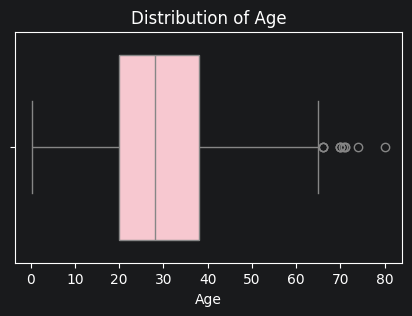

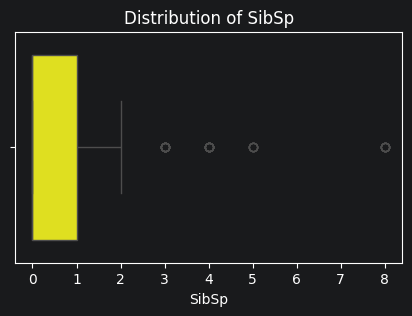

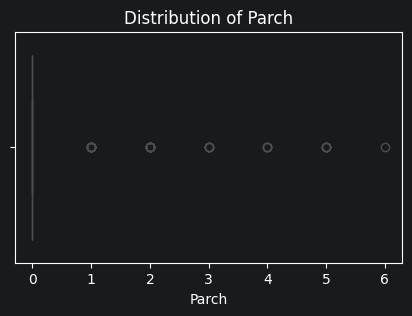

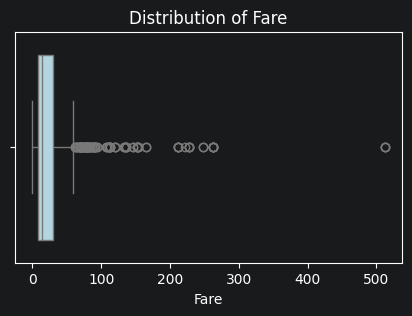

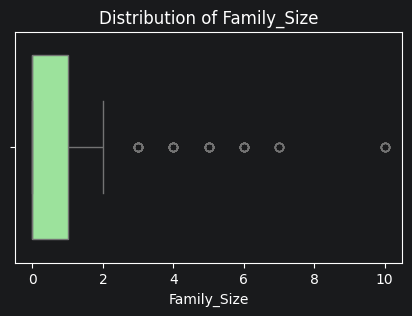

In [317]:
def Boxplot(feature, color):
    plt.figure(figsize=(5, 3))
    sns.boxplot(x=titanic_df[feature].dropna(), color=color)
    plt.title('Distribution of ' + feature)
    plt.xlabel(feature)
    plt.show()
Boxplot('Age', 'pink')
Boxplot('SibSp', 'yellow')
Boxplot('Parch', 'orange')
Boxplot('Fare', 'lightblue')
Boxplot('Family_Size', 'lightgreen')


Wszytkie wartości odstające są możliwe, zatem zostawię je.
Dla danych kategorycznych policzę ilość każdej wystepujacej wartości.

In [318]:
def valueCounts(feature):
    return titanic_df[feature].value_counts()
print(valueCounts('Is_Female'))
print(valueCounts('Survived'))
print(valueCounts('Pclass'))
print(valueCounts('Fare_Category'))
print(valueCounts('Age_Category'))
print(valueCounts('Cabin_Type_Frequency'))
valueCounts('Embarked_coded')

Is_Female
0    577
1    314
Name: count, dtype: int64
Survived
0    549
1    342
Name: count, dtype: int64
Pclass
3    491
1    216
2    184
Name: count, dtype: int64
Fare_Category
2    295
1    291
3    158
4     98
5     49
Name: count, dtype: int64
Age_Category
3    386
4    306
5     98
1     51
2     50
Name: count, dtype: int64
Cabin_Type_Frequency
0.771    687
0.066     59
0.053     47
0.037     33
0.036     32
0.017     15
0.015     13
0.004      4
0.001      1
Name: count, dtype: int64


Embarked_coded
3    646
1    168
2     77
Name: count, dtype: int64

Wszystkie outliery są prawdopodobne, zatem nie usuwam żadnych wartości.


### 5. Wykresy

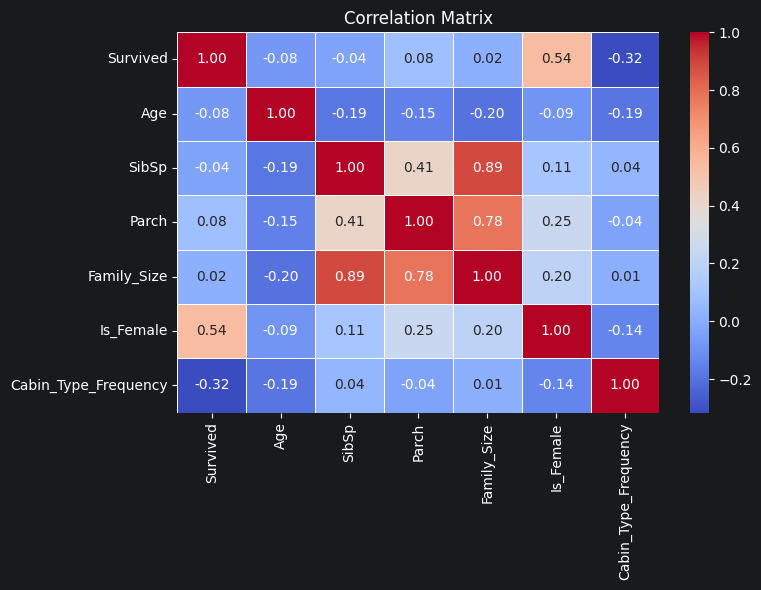

In [319]:
data = titanic_df[['Survived', 'Age', 'SibSp', 'Parch', 'Family_Size', 'Is_Female', 'Cabin_Type_Frequency']]
plt.figure(figsize=(8,6))
sns.heatmap(data.corr(), annot=True, fmt=".2f", cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Matrix')
plt.tight_layout()
plt.show()

Można z wykresu odczytać pewne ciekawe dane. Większą szansę na przetrwanie mają kobiety. Najczęściej występującą kabiną była wartość 'unknown'. Im rzadziej występujący rodzaj kabiny, tym większe szanse na przetrwanie. Wynika z tego, że osoby, które podały nazwę kabiny, częściej przeżywały. Można też zaobserwować pewne zależności niemające znaczenia w kontekście przetrwania. Np. więcej kobiet miało dużo rodziny na pokładzie.

Dla danych kategorialnych utworzę wykresy.

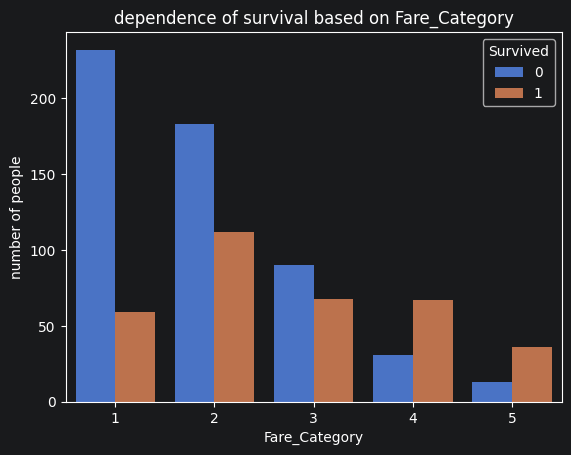

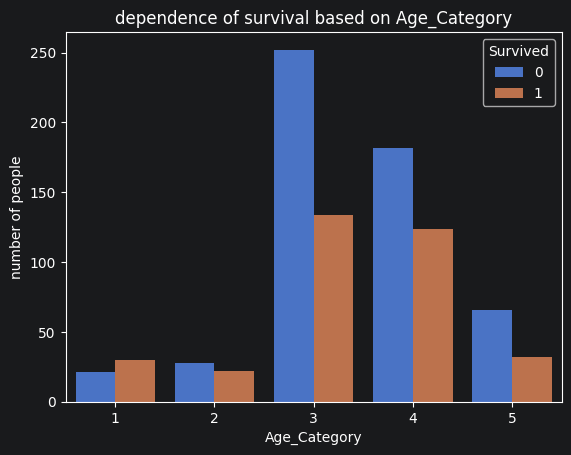

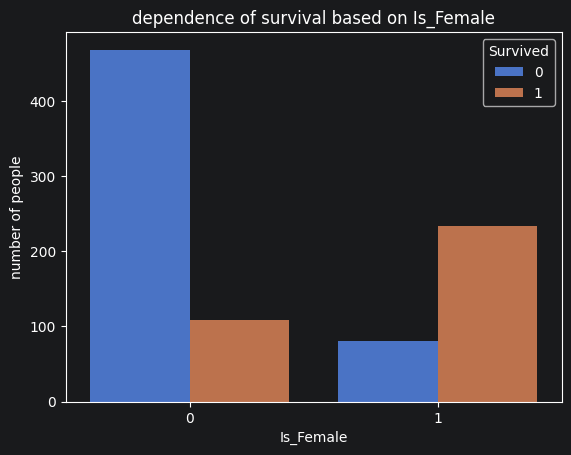

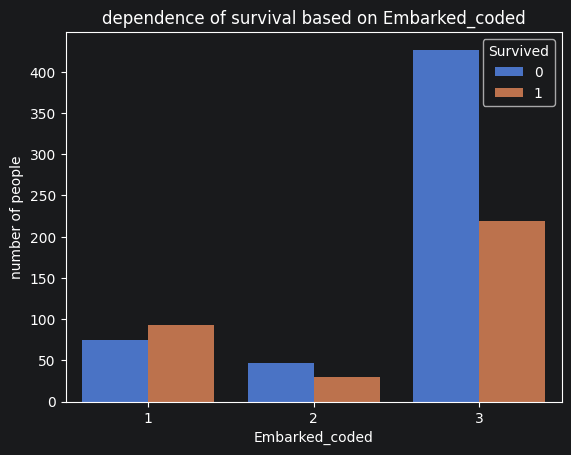

In [320]:
def survival_based_on_category(feature):
    sns.countplot(data=titanic_df, x=feature ,hue="Survived")
    plt.title("dependence of survival based on " + feature)
    plt.xlabel(feature)
    plt.ylabel("number of people")
    return plt.show()
survival_based_on_category('Fare_Category')
survival_based_on_category('Age_Category')
survival_based_on_category('Is_Female')
survival_based_on_category('Embarked_coded')

Z wykresów powyżej wynika, że na przeżycie miała wpływ kategoria utworzona dla cen biletu - im droższy bilet, tym większe szanse na przetrwanie. Z drugiego wykresu wynika, że najwięcej przeżyło dzieci do lat 5. Prawdopodobnie miały pierszeństwo w dostawaniu się na szalupę ratowniczą. Tak jak na wykresie correlation matrix widać na trzecim wykresie, że przeżyło znacznie więcej kobiet. Co ciekawe warto zauważyć, że na przeżycie miało wpływ miejsce wsiadania pasażera.(ostatni wykres) Najwięcej osób przeżyło z ortu pierwszego - portu C.